# PINN — 1D Burgers' Equation

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\\partial x} = \nu\frac{\partial^2 u}{\partial x^2}, \quad x \in [-1,1],\ t \in [0,1]$$

**IC:** $u(x,0) = -\sin(\pi x)$  
**BC:** $u(-1,t) = u(1,t) = 0$  
**점성:** $\nu = 0.01/\pi$

In [10]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pinns import PINN

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Problem Setup

In [12]:
NU = 0.01 / np.pi   # 점성 계수 (원 논문과 동일)

def ic(x):
    """Initial condition: u(x, 0) = -sin(pi*x)"""
    return -np.sin(np.pi * x)

# Sanity: IC at x=0 → 0, at x=0.5 → -1
assert np.isclose(ic(0.0), 0.0)
assert np.isclose(ic(0.5), -1.0)
print(f"nu = {NU:.6f}")
print("IC sanity check passed.")

nu = 0.003183
IC sanity check passed.


## 2. Data Generation

In [13]:
N_pde = 10000
N_ic  = 256
N_bc  = 200   # 각 경계 100개

# --- PDE collocation: uniform in [-1,1] x [0,1] ---
x_col = np.random.uniform(-1, 1, (N_pde, 1))
t_col = np.random.uniform( 0, 1, (N_pde, 1))
x_pde = torch.tensor(
    np.hstack([x_col, t_col]), dtype=torch.float32, device=device
)

# --- IC: t=0, u = -sin(pi*x) ---
x_ic_np = np.linspace(-1, 1, N_ic)[:, None]
x_ic = torch.tensor(
    np.hstack([x_ic_np, np.zeros((N_ic, 1))]),
    dtype=torch.float32, device=device
)
u_ic = torch.tensor(ic(x_ic_np), dtype=torch.float32, device=device)  # (N_ic, 1)

# --- BC: u(-1, t) = 0,  u(1, t) = 0 ---
t_bc_np = np.linspace(0, 1, N_bc // 2)[:, None]
x_bc_left  = torch.tensor(np.hstack([np.full((N_bc//2, 1), -1.0), t_bc_np]),
                           dtype=torch.float32, device=device)
x_bc_right = torch.tensor(np.hstack([np.full((N_bc//2, 1),  1.0), t_bc_np]),
                           dtype=torch.float32, device=device)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
u_bc = torch.zeros(N_bc, 1, device=device)

print(f"PDE : {x_pde.shape}")
print(f"IC  : {x_ic.shape}   target: {u_ic.shape}")
print(f"BC  : {x_bc.shape}   target: {u_bc.shape}")

PDE : torch.Size([10000, 2])
IC  : torch.Size([256, 2])   target: torch.Size([256, 1])
BC  : torch.Size([200, 2])   target: torch.Size([200, 1])


## 3. PDE Residual

$$\mathcal{R} = u_t + u\,u_x - \nu\,u_{xx}$$

In [14]:
def burgers_residual(model, xt):
    """
    Burgers' PDE residual: u_t + u*u_x - nu*u_xx = 0
    xt : [N, 2]  (x, t),  requires_grad=True
    """
    u = model(xt)                                       # [N, 1]

    # 1차 미분
    grads = torch.autograd.grad(
        u, xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]                                                # [N, 2]
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    # 2차 미분
    u_xx = torch.autograd.grad(
        u_x, xt,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]

    return u_t + u * u_x - NU * u_xx

## 4. Model & Training

In [15]:
model = PINN(
    layers=[2, 64, 64, 64, 64, 64, 1],
    activation="tanh",
    residual=False,
    skip=True,
    use_fourier=False,
    use_ntk=False,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 33,473


In [ ]:
model.fit(
    pde_fn=burgers_residual,
    x_pde=x_pde,
    x_bc=x_bc,
    u_bc=u_bc,
    x_ic=x_ic,
    u_ic=u_ic,
    # x_ic_ut 없음 — Burgers는 1차 시간 PDE
    epochs=20000,
    lr=1e-3,
    w_pde=1.0,
    w_bc=1.0,
    w_ic=1.0,
    ntk_adaptive=False,
    log_every=500,
    save_path="./checkpoints/best_burgers.pt",
)

## 5. Loss History

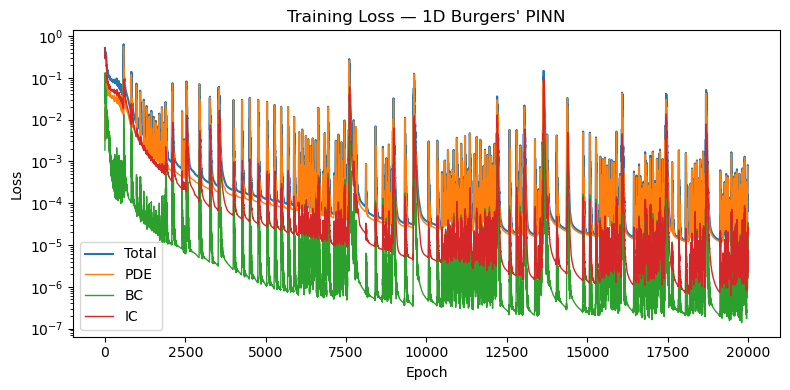

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(model.loss_history["total"], label="Total",  lw=1.5)
ax.semilogy(model.loss_history["pde"],   label="PDE",    lw=1)
ax.semilogy(model.loss_history["bc"],    label="BC",     lw=1)
ax.semilogy(model.loss_history["ic"],    label="IC",     lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss — 1D Burgers' PINN")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Reference Solution (burgers_shock.mat)

In [ ]:
import scipy.io as sio

data   = sio.loadmat("./data/burgers_shock.mat")
x_mat  = data["x"].ravel()      # (256,)
t_mat  = data["t"].ravel()      # (100,)
usol   = data["usol"]           # (256, 100): usol[i_x, i_t]

print(f"x : {x_mat.shape}  [{x_mat.min():.3f}, {x_mat.max():.3f}]")
print(f"t : {t_mat.shape}  [{t_mat.min():.3f}, {t_mat.max():.3f}]")
print(f"usol : {usol.shape}  [{usol.min():.3f}, {usol.max():.3f}]")

## 7. Heatmap: $u(x,t)$ 

In [ ]:
XX, TT = np.meshgrid(x_mat, t_mat)   # (100, 256)
U_ref  = usol.T                       # (100, 256): [i_t, i_x]

model.load_state_dict(torch.load("./checkpoints/best_burgers.pt", weights_only=True))
model.eval()
xt_test = torch.tensor(
    np.stack([XX.ravel(), TT.ravel()], axis=1),
    dtype=torch.float32, device=device
)
with torch.no_grad():
    U_pred = model(xt_test).cpu().numpy().reshape(len(t_mat), len(x_mat))

U_err = np.abs(U_pred - U_ref)
vabs  = np.abs(U_ref).max()
kw    = dict(origin="lower", extent=[x_mat.min(), x_mat.max(),
                                     t_mat.min(), t_mat.max()], aspect="auto")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(U_ref,  cmap="RdBu_r", vmin=-vabs, vmax=vabs, **kw)
axes[0].set_title("Reference $u(x,t)$")
axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$t$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred, cmap="RdBu_r", vmin=-vabs, vmax=vabs, **kw)
axes[1].set_title("PINN $u(x,t)$")
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("$t$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(U_err,  cmap="hot",    vmin=0,     **kw)
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("$x$"); axes[2].set_ylabel("$t$")
plt.colorbar(im2, ax=axes[2])

# slice 위치 표시
t_slices = [0.25, 0.50, 0.75]
for ax in axes[:2]:
    for ts in t_slices:
        ax.axhline(ts, color="k", lw=0.8, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

rel_l2 = np.linalg.norm(U_pred - U_ref) / (np.linalg.norm(U_ref) + 1e-10)
print(f"Relative L2 error (full domain): {rel_l2:.4e}")

## 8. Slice Comparison

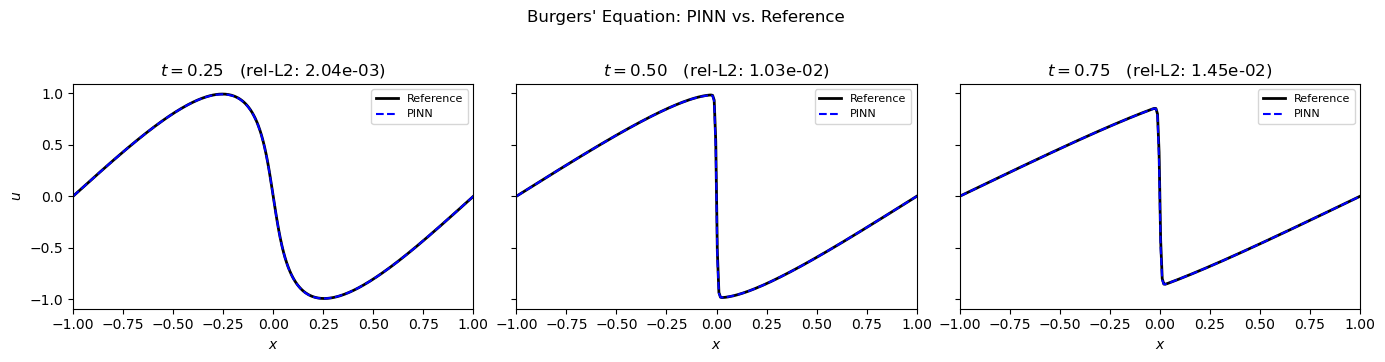

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for ax, ts in zip(axes, t_slices):
    t_idx = int(np.argmin(np.abs(t_mat - ts)))
    t_val = t_mat[t_idx]

    ax.plot(x_mat, U_ref[t_idx],  "k-",  lw=2,   label="Reference")
    ax.plot(x_mat, U_pred[t_idx], "b--", lw=1.5, label="PINN")

    err_t = np.linalg.norm(U_pred[t_idx] - U_ref[t_idx]) / (np.linalg.norm(U_ref[t_idx]) + 1e-10)
    ax.set_title(f"$t = {t_val:.2f}$   (rel-L2: {err_t:.2e})")
    ax.set_xlabel("$x$")
    ax.legend(fontsize=8)
    ax.set_xlim(-1, 1)

axes[0].set_ylabel("$u$")
plt.suptitle("Burgers' Equation: PINN vs. Reference", y=1.02)
plt.tight_layout()
plt.show()